# 02 - Knee Model Setup

We verify the nominal knee dynamics and simulate a simple tracking controller.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

ROOT = Path(r"e:/Optimal_Control/PINN/hjb_pinn_exoskeleton")
sys.path.append(str(ROOT))

from src.knee_dynamics import ExoParams, knee_dynamics_numpy
from src.utils import set_global_seed

cfg = yaml.safe_load((ROOT / "configs" / "knee_config.yaml").read_text())
set_global_seed(cfg["seed"])

exo_cfg = cfg["exo_params"]
params = ExoParams(**exo_cfg)

params


ExoParams(I=0.25, B=0.1, m=5.0, g=9.81, l=0.25)

## Sanity Checks


In [2]:
# q = 0, qdot = 0, u = 0 -> qddot = 0
x0 = np.array([0.0, 0.0], dtype=float)
print(knee_dynamics_numpy(x0, 0.0, params))

# q = pi/2, qdot = 0, u = 0 -> qddot negative
x1 = np.array([np.pi/2, 0.0], dtype=float)
print(knee_dynamics_numpy(x1, 0.0, params))


[0. 0.]
[  0.   -49.05]


## Simple Tracking Simulation (PD)
We track a synthetic sinusoidal knee angle using a PD controller.


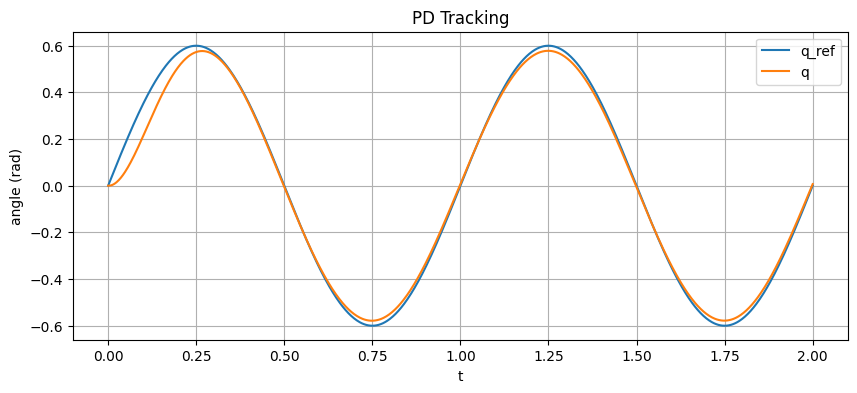

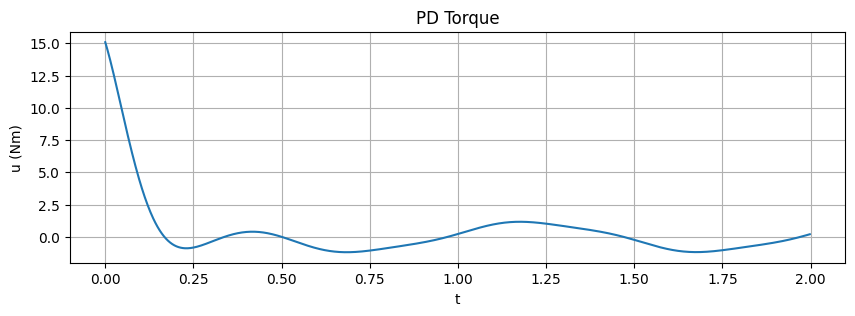

In [3]:
def simulate_pd(params, T=2.0, dt=0.002, kp=40.0, kd=4.0):
    steps = int(T / dt)
    t = np.linspace(0.0, T, steps + 1)
    q_ref = 0.6 * np.sin(2 * np.pi * t)
    qd_ref = 0.6 * 2 * np.pi * np.cos(2 * np.pi * t)

    x = np.array([0.0, 0.0], dtype=float)
    xs = [x.copy()]
    us = []
    for k in range(steps):
        q, qd = x
        u = -kp * (q - q_ref[k]) - kd * (qd - qd_ref[k])
        dx = knee_dynamics_numpy(x, u, params)
        x = x + dt * dx
        xs.append(x.copy())
        us.append(u)
    xs = np.array(xs)
    us = np.array(us)
    return t, q_ref, xs, us

T = 2.0
t, q_ref, xs, us = simulate_pd(params, T=T)

plt.figure(figsize=(10, 4))
plt.plot(t, q_ref, label="q_ref")
plt.plot(t, xs[:, 0], label="q")
plt.title("PD Tracking")
plt.xlabel("t")
plt.ylabel("angle (rad)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t[:-1], us)
plt.title("PD Torque")
plt.xlabel("t")
plt.ylabel("u (Nm)")
plt.grid(True)
plt.show()
